In [8]:
# Imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [9]:
# Import timestamp results
best_case_baseline_df = pd.read_csv(filepath_or_buffer="../timestamp_results/recipe-id-1-eval/bc-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
worst_case_baseline_df = pd.read_csv(filepath_or_buffer="../timestamp_results/recipe-id-1-eval/wc-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
reconfigure_df = pd.read_csv(filepath_or_buffer="../timestamp_results/recipe-id-1-eval/reconfigure-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)
rearrange_df = pd.read_csv(filepath_or_buffer="../timestamp_results/recipe-id-1-eval/rearrange-50-orders-completed-orders-#0.csv", header=0, sep=',', dtype=np.longlong)

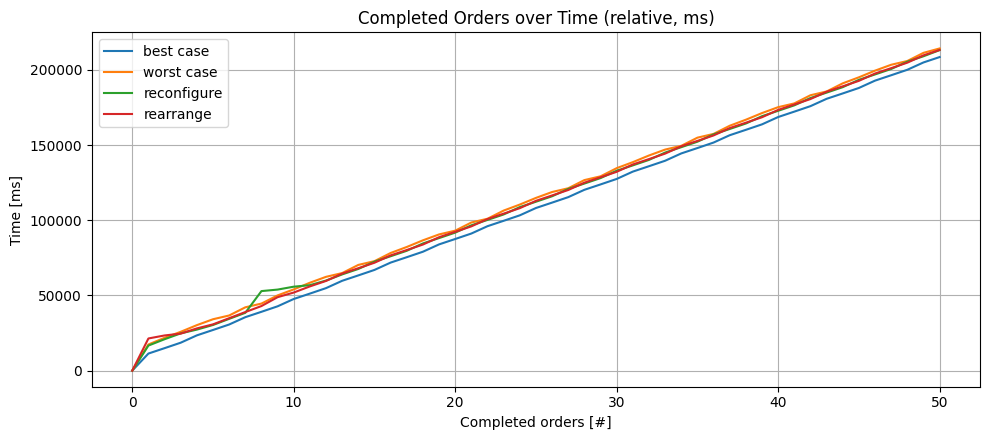

In [10]:
def add_rel_ms(timestamp_df):
    timestamp_start_ts = timestamp_df['TIMESTAMP'].iloc[0]
    timestamp_df['rel_ms'] = (timestamp_df['TIMESTAMP'] - timestamp_start_ts) / 1e6
    return timestamp_df

timestamp_dfs = [add_rel_ms(df) for df in [best_case_baseline_df, worst_case_baseline_df, reconfigure_df, rearrange_df]]
labels = ['best case', 'worst case', 'reconfigure', 'rearrange']

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
for timestamp_df,label in zip(timestamp_dfs,labels):
    plt.plot(timestamp_df['COMPLETED_ORDER_COUNT'], timestamp_df['rel_ms'], label=label)
plt.xlabel('Completed orders [#]')
plt.ylabel('Time [ms]')
plt.title('Completed Orders over Time (relative, ms)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [11]:
print("best case baseline makespan: {0} ms".format(timestamp_dfs[0]['rel_ms'].iloc[-1]))
print("worst case baseline makespan: {0} ms, {1}% slower than best case".format(timestamp_dfs[1]['rel_ms'].iloc[-1], (1-timestamp_dfs[0]['rel_ms'].iloc[-1]/timestamp_dfs[1]['rel_ms'].iloc[-1])*1e2))
print("reconfigure makespan: {0} ms, {1}% faster than worst case".format(timestamp_dfs[2]['rel_ms'].iloc[-1], (1-timestamp_dfs[2]['rel_ms'].iloc[-1]/timestamp_dfs[1]['rel_ms'].iloc[-1])*1e2))
print("rearrange makespan: {0} ms, {1}% faster than worst case".format(timestamp_dfs[3]['rel_ms'].iloc[-1], (1-timestamp_dfs[3]['rel_ms'].iloc[-1]/timestamp_dfs[1]['rel_ms'].iloc[-1])*1e2))

best case baseline makespan: 208601.437231 ms
worst case baseline makespan: 214334.472355 ms, 2.674807771707599% slower than best case
reconfigure makespan: 213217.741196 ms, 0.5210226552592956% faster than worst case
rearrange makespan: 213323.863157 ms, 0.4715103393756137% faster than worst case


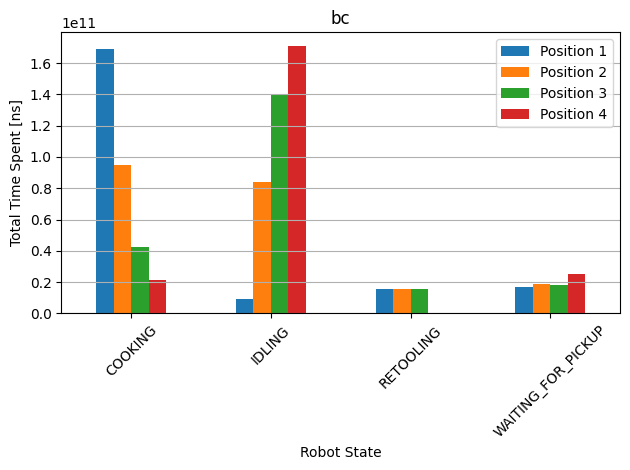

Total time recorded for Position 1: 210.57 seconds
Total time recorded for Position 1 without IDLING: 201.43 seconds
Total time recorded for Position 2: 213.66 seconds
Total time recorded for Position 2 without IDLING: 129.75 seconds
Total time recorded for Position 3: 215.82 seconds
Total time recorded for Position 3 without IDLING: 75.90 seconds
Total time recorded for Position 4: 217.23 seconds
Total time recorded for Position 4 without IDLING: 46.15 seconds


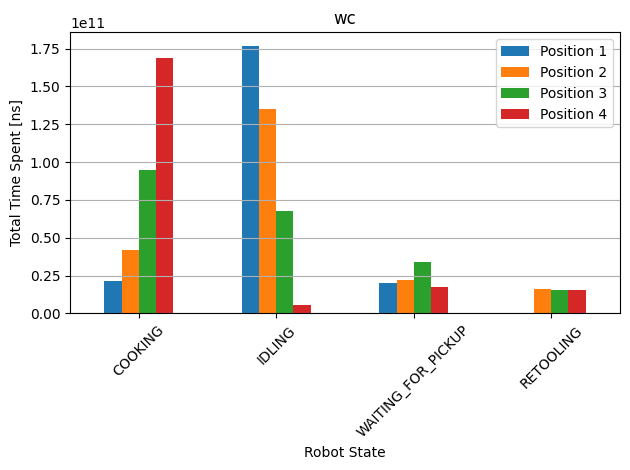

Total time recorded for Position 1: 218.22 seconds
Total time recorded for Position 1 without IDLING: 41.28 seconds
Total time recorded for Position 2: 215.31 seconds
Total time recorded for Position 2 without IDLING: 80.05 seconds
Total time recorded for Position 3: 211.88 seconds
Total time recorded for Position 3 without IDLING: 144.37 seconds
Total time recorded for Position 4: 207.37 seconds
Total time recorded for Position 4 without IDLING: 201.47 seconds


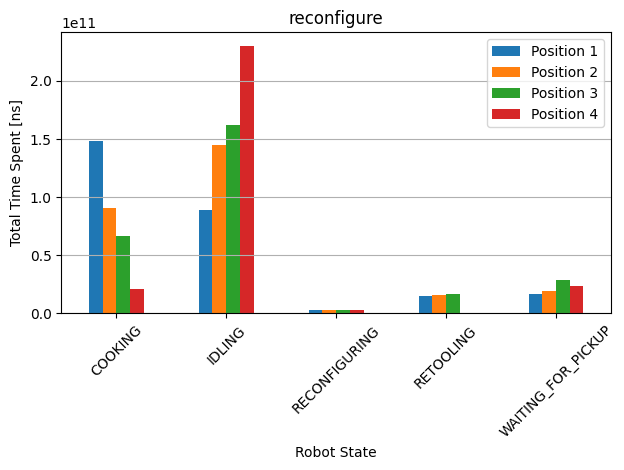

Total time recorded for Position 1: 271.49 seconds
Total time recorded for Position 1 without IDLING: 182.64 seconds
Total time recorded for Position 2: 274.47 seconds
Total time recorded for Position 2 without IDLING: 129.28 seconds
Total time recorded for Position 3: 276.64 seconds
Total time recorded for Position 3 without IDLING: 114.56 seconds
Total time recorded for Position 4: 278.06 seconds
Total time recorded for Position 4 without IDLING: 47.80 seconds


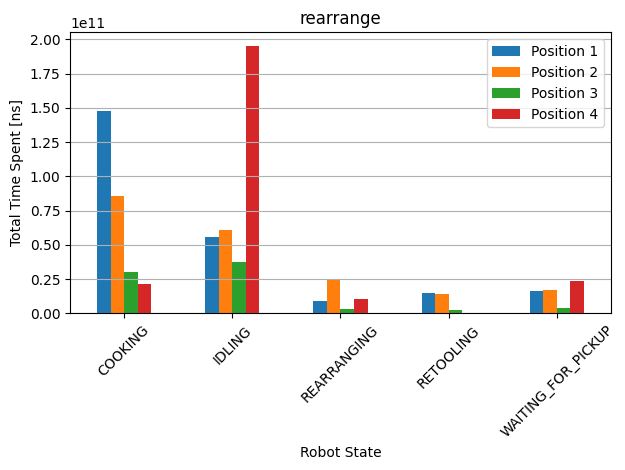

Total time recorded for Position 1: 243.47 seconds
Total time recorded for Position 1 without IDLING: 187.80 seconds
Total time recorded for Position 2: 202.05 seconds
Total time recorded for Position 2 without IDLING: 140.91 seconds
Total time recorded for Position 3: 78.27 seconds
Total time recorded for Position 3 without IDLING: 40.49 seconds
Total time recorded for Position 4: 250.13 seconds
Total time recorded for Position 4 without IDLING: 54.79 seconds


In [12]:
from enum import IntEnum

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}

# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df):
    t0 = robot_stats_df['TIMESTAMP'].iloc[0]
    robot_stats_df['rel_ns'] = robot_stats_df['TIMESTAMP'] - t0
    robot_times_spent_df = pd.DataFrame({
        'STATE_NAME': pd.Series(dtype='object'),
        'DURATION_NS': pd.Series(dtype='int64')
    })

    state_key = robot_stats_df['STATE'].iloc[0]
    start_time = robot_stats_df['rel_ns'].iloc[0]

    for _, row in robot_stats_df.iterrows():
        if row['STATE'] != state_key:
            end_time = row['rel_ns']
            time_in_state = end_time - start_time
            state_name = ROBOT_STATE_NAME[state_key]

            # append a row
            robot_times_spent_df = pd.concat(
                [
                    robot_times_spent_df,
                    pd.DataFrame(
                        {'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]}
                    )
                ],
                ignore_index=True,
            )

            state_key = row['STATE']
            start_time = row['rel_ns']

    # handle last segment until the last timestamp
    end_time = robot_stats_df['rel_ns'].iloc[-1]
    time_in_state = end_time - start_time
    state_name = ROBOT_STATE_NAME[state_key]
    robot_times_spent_df = pd.concat(
        [
            robot_times_spent_df,
            pd.DataFrame({'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]})
        ],
        ignore_index=True,
    )
    return robot_times_spent_df

def plot_statistics(statistics_df, title):
    # Extract list of robot positions present in the dataframe
    positions = sorted(statistics_df['ROBOT_POSITION'].unique().tolist())
    position_dfs = [(statistics_df[statistics_df['ROBOT_POSITION'] == position].copy()) for position in positions]
    time_spent_dfs = [analyze_time_spent_per_state(pos_df) for pos_df in position_dfs]
    aggregated_time_spent_dfs = []
    for time_spent_df in time_spent_dfs:
        aggregated_df = (
            time_spent_df
            .groupby('STATE_NAME', as_index=False)['DURATION_NS']
            .sum()
        )
        aggregated_time_spent_dfs.append(aggregated_df)

    combined = pd.DataFrame()
    for i, df in enumerate(aggregated_time_spent_dfs):
        # Set STATE_NAME as index
        df = df.set_index("STATE_NAME")
        # Rename the DURATION_NS column
        df = df.rename(columns={"DURATION_NS": f"Position {i+1}"})
        # Add the column to the combined DF
        combined = pd.concat([combined, df], axis=1)
    combined = combined.fillna(0)

    ax = combined.plot.bar(rot=45, title=title)
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [ns]')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Sum up total time
    for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
        total_time_ns = aggregated_df['DURATION_NS'].sum()
        print(f"Total time recorded for Position {i+1}: {total_time_ns / 1e9:.2f} seconds")
        total_time_without_idling_ns = aggregated_df[aggregated_df['STATE_NAME'] != 'IDLING']['DURATION_NS'].sum()
        print(f"Total time recorded for Position {i+1} without IDLING: {total_time_without_idling_ns / 1e9:.2f} seconds")

# Import statistics results
statistics_bc_baseline_df = pd.read_csv(filepath_or_buffer="../statistic_results/recipe-id-1-eval/bc-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
statistics_wc_baseline_df = pd.read_csv(filepath_or_buffer="../statistic_results/recipe-id-1-eval/wc-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
statistics_reconfigure_df = pd.read_csv(filepath_or_buffer="../statistic_results/recipe-id-1-eval/reconfigure-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
statistics_rearrange_df = pd.read_csv(filepath_or_buffer="../statistic_results/recipe-id-1-eval/rearrange-50-orders-robot-statistics-#0.csv", header=0, sep=',', dtype=np.longlong)
statistics_dfs = [(statistics_bc_baseline_df,'bc'), (statistics_wc_baseline_df, 'wc'), (statistics_reconfigure_df, 'reconfigure'), (statistics_rearrange_df, 'rearrange')]
for statistic_df, label in statistics_dfs:
    plot_statistics(statistic_df,label)

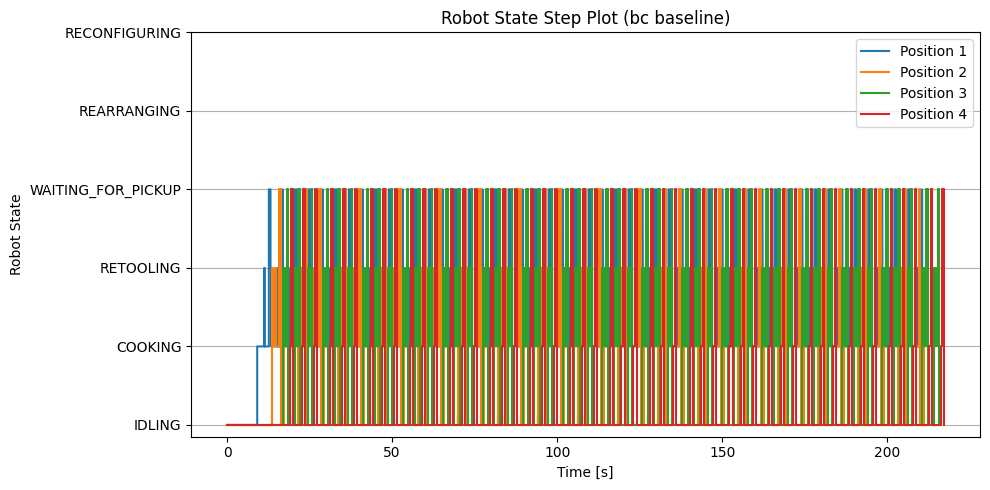

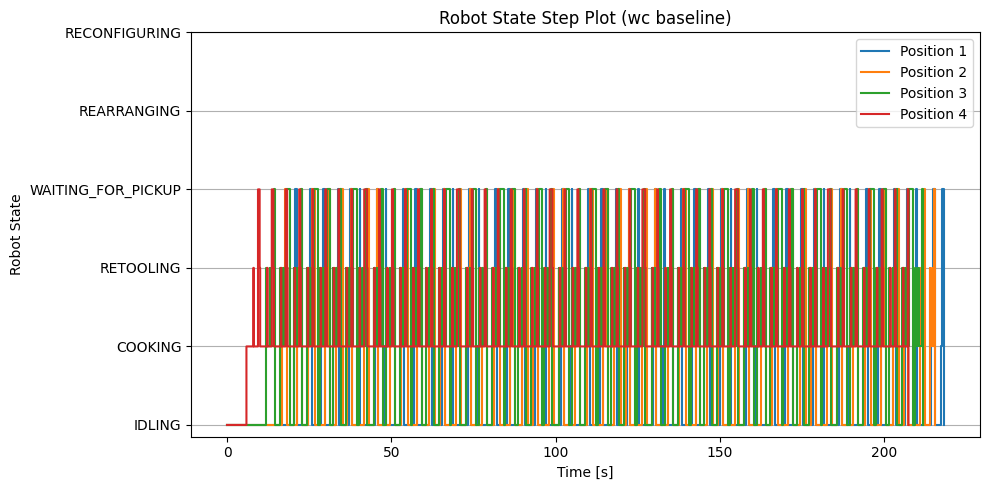

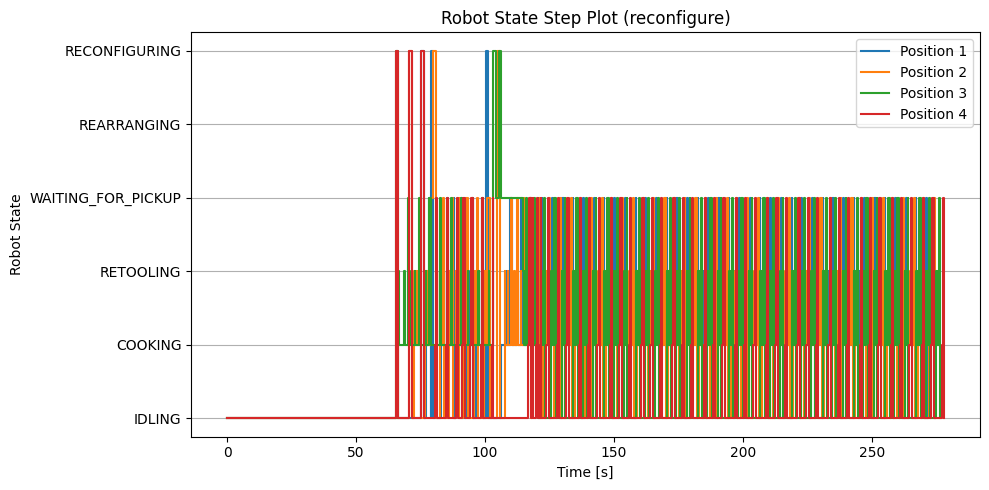

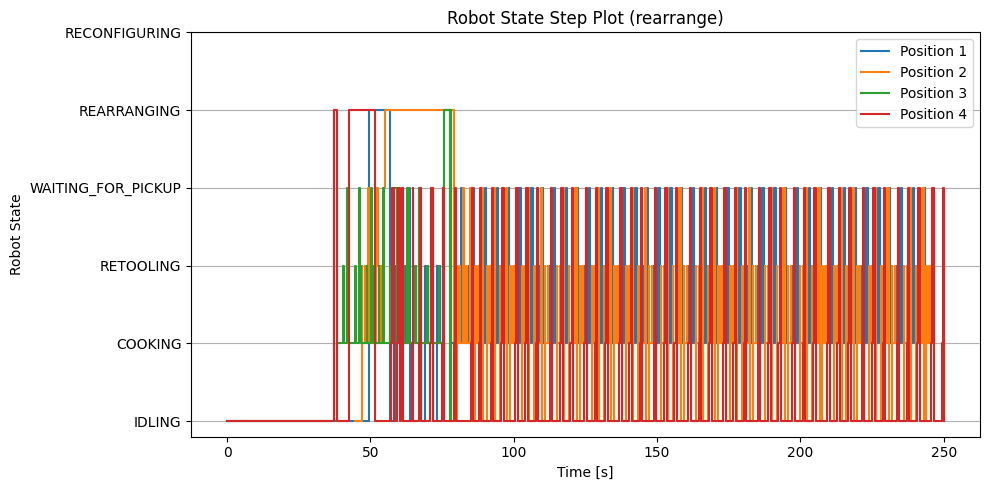

In [13]:
def add_rel_s(statistics_df):
    timestamp_start_ts = statistics_df['TIMESTAMP'].iloc[0]
    statistics_df['rel_s'] = (statistics_df['TIMESTAMP'] - timestamp_start_ts) / 1e9
    return statistics_df

def plot_step_plot(statistics_df, title_addition):
    plt.figure(figsize=(10, 5))
    positions = sorted(statistics_df['ROBOT_POSITION'].unique().tolist())
    for pos in positions:
        pos_df = statistics_df[statistics_df['ROBOT_POSITION'] == pos]
        plt.step(pos_df['rel_s'], pos_df['STATE'], where='post', label=f'Position {pos}')

    # Map y-ticks to state names
    state_vals = sorted(ROBOT_STATE_NAME.keys())
    plt.yticks(state_vals, [ROBOT_STATE_NAME[v] for v in state_vals])

    plt.xlabel('Time [s]')
    plt.ylabel('Robot State')
    plt.title(f'Robot State Step Plot ({title_addition})')
    plt.grid(True, axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

stat_dfs = [add_rel_s(df) for df in [statistics_bc_baseline_df, statistics_wc_baseline_df, statistics_reconfigure_df, statistics_rearrange_df]]
titles = ['bc baseline', 'wc baseline', 'reconfigure', 'rearrange']
for stat_df, title in zip(stat_dfs, titles):
    plot_step_plot(stat_df, title)

